<a href="https://colab.research.google.com/github/Rakeshatla/resume_categorization/blob/main/new%2Cnew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import pandas as pd
# import numpy as np
# import re
# import nltk
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize
# from nltk.stem import WordNetLemmatizer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.svm import SVC
# from sklearn.multiclass import OneVsRestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from imblearn.over_sampling import SMOTE
# import pickle
# import logging
# !pip install pdfminer.six
# from pdfminer.high_level import extract_text
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Setup logging
# logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# # Download NLTK resources (run once)
# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('punkt_tab')

# # Load dataset
# df = pd.read_csv('UpdatedResumeDataSet.csv')
# logging.info("Dataset loaded. Shape: %s", df.shape)

# # Check for missing values
# if df.isnull().sum().any():
#     logging.warning("Missing values detected. Dropping rows with NaN.")
#     df = df.dropna()

# # Define custom stopwords
# custom_stopwords = set(stopwords.words('english')).union({'cv', 'resume', 'references', 'page', 'email'})

# # Optimized text cleaning function
# def clean_resume(txt):
#     if not isinstance(txt, str):
#         return ""
#     txt = txt.lower()
#     txt = re.sub(r'http\S+|#\S+|@\S+|[^\w\s]|\d+', ' ', txt)
#     txt = re.sub(r'\s+', ' ', txt).strip()
#     words = word_tokenize(txt)
#     words = [word for word in words if word not in custom_stopwords]
#     lemmatizer = WordNetLemmatizer()
#     words = [lemmatizer.lemmatize(word) for word in words]
#     return ' '.join(words)

# # Apply cleaning
# logging.info("Cleaning resumes...")
# df['Resume'] = df['Resume'].apply(clean_resume)
# logging.info("Sample cleaned resume: %s", df['Resume'].iloc[0])

# # Encode labels
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['Category'] = le.fit_transform(df['Category'])
# with open("label_encoder.pkl", "wb") as f:
#     pickle.dump(le, f)

# # TF-IDF Vectorization with n-grams
# tfidf = TfidfVectorizer(max_features=5000, stop_words=list(custom_stopwords), ngram_range=(1, 2))
# X_tfidf = tfidf.fit_transform(df['Resume'])
# y = df['Category']
# with open("tfidf.pkl", "wb") as f:
#     pickle.dump(tfidf, f)
# logging.info("TF-IDF shape: %s", X_tfidf.shape)

# # Apply SMOTE
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)
# logging.info("Balanced category distribution:\n%s", pd.Series(y_resampled).value_counts())

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
# )
# logging.info("Training set shape: %s, Testing set shape: %s", X_train.shape, X_test.shape)

# # Model training with hyperparameter tuning
# param_grid = {'estimator__C': [0.1, 1, 10], 'estimator__kernel': ['linear']}
# model = GridSearchCV(OneVsRestClassifier(SVC(random_state=42)), param_grid, cv=5, scoring='accuracy')
# model.fit(X_train, y_train)
# logging.info("Best parameters: %s", model.best_params_)
# logging.info("Best cross-validation score: %.4f", model.best_score_)

# # Save the model
# with open("svm_model.pkl", "wb") as f:
#     pickle.dump(model.best_estimator_, f)

# # Evaluation
# y_pred = model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)
# logging.info("SVM Accuracy: %.4f", accuracy)
# logging.info("Classification Report:\n%s", classification_report(y_test, y_pred))

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.show()

# # Skills list for extraction
# skills_list = [
#     'Python', 'Data Analysis', 'Machine Learning', 'SQL', 'Java', 'C++', 'JavaScript', 'HTML', 'CSS', 'React',
#     'Git', 'Statistics', 'R', 'Tableau', 'Pandas', 'Numpy', 'Scikit-learn', 'TensorFlow', 'AWS', 'Docker'
#     # Add more skills as needed
# ]

# # Prediction function
# def predict_category(pdf_path, model, tfidf, le, skills_list):
#     try:
#         text = extract_text(pdf_path)
#         if not text:
#             return "Error: No text extracted", []
#         cleaned_text = clean_resume(text)
#         extracted_skills = extract_skills_from_resume(text, skills_list)
#         vectorized_input = tfidf.transform([cleaned_text])
#         predicted_label = model.predict(vectorized_input)
#         predicted_category = le.inverse_transform(predicted_label)[0]
#         return predicted_category, extracted_skills
#     except Exception as e:
#         logging.error("Prediction error: %s", e)
#         return "Error during prediction", []

# def extract_skills_from_resume(text, skills_list):
#     skills = []
#     for skill in skills_list:
#         pattern = r"\b{}\b".format(re.escape(skill))
#         if re.search(pattern, text, re.IGNORECASE):
#             skills.append(skill)
#     return skills

# # Example usage
# resume_path = "Nachiketh_s_CV(8).pdf"  # Update with your path
# category, skills = predict_category(resume_path, model.best_estimator_, tfidf, le, skills_list)
# logging.info("Predicted Job Category: %s", category)
# logging.info("Extracted Skills: %s", skills)

#  Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import pickle
import logging
import seaborn as sns
import matplotlib.pyplot as plt

# PDF extraction
!pip install pdfminer.six
from pdfminer.high_level import extract_text


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 101.7 MB/s eta 0:00:00


# Setup Logging and NLTK

In [ ]:
# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Load and Preprocess Dataset

In [ ]:
# Load dataset
df = pd.read_csv('/content/UpdatedResumeDataSet.csv')
logging.info("Dataset loaded. Shape: %s", df.shape)

# Handle missing values
if df.isnull().sum().any():
    logging.warning("Missing values detected. Dropping rows with NaN.")
    df = df.dropna()


# Clean Resume Text


In [ ]:
# Define stopwords
custom_stopwords = set(stopwords.words('english')).union({'cv', 'resume', 'references', 'page', 'email'})

# Text cleaning function
def clean_resume(txt):
    if not isinstance(txt, str):
        return ""
    txt = txt.lower()
    txt = re.sub(r'http\S+|#\S+|@\S+|[^\w\s]|\d+', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    words = word_tokenize(txt)
    words = [word for word in words if word not in custom_stopwords]
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

# Apply cleaning
logging.info("Cleaning resumes...")
df['Resume'] = df['Resume'].apply(clean_resume)
logging.info("Sample cleaned resume: %s", df['Resume'].iloc[0])


# Encode Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


#  TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, stop_words=list(custom_stopwords), ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['Resume'])
y = df['Category']

# Save TF-IDF
with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

logging.info("TF-IDF shape: %s", X_tfidf.shape)


# Balance Dataset with SMOTE

In [ ]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)

logging.info("Balanced category distribution:\n%s", pd.Series(y_resampled).value_counts())


# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)
logging.info("Training set shape: %s, Testing set shape: %s", X_train.shape, X_test.shape)


# Model Training with Grid Search

In [ ]:
param_grid = {'estimator__C': [0.1, 1, 10], 'estimator__kernel': ['linear']}
model = GridSearchCV(OneVsRestClassifier(SVC(random_state=42)), param_grid, cv=5, scoring='accuracy')
model.fit(X_train, y_train)

logging.info("Best parameters: %s", model.best_params_)
logging.info("Best cross-validation score: %.4f", model.best_score_)

# Save the best model
with open("svm_model.pkl", "wb") as f:
    pickle.dump(model.best_estimator_, f)


# Evaluation



Accuracy: 0.9976190476190476

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        17
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        17
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        17
           8       1.00      0.94      0.97        16
           9       1.00      1.00      1.00        17
          10       1.00      1.00      1.00        17
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        17
          13       1.00      1.00      1.00        17
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        17
          16       1.00    

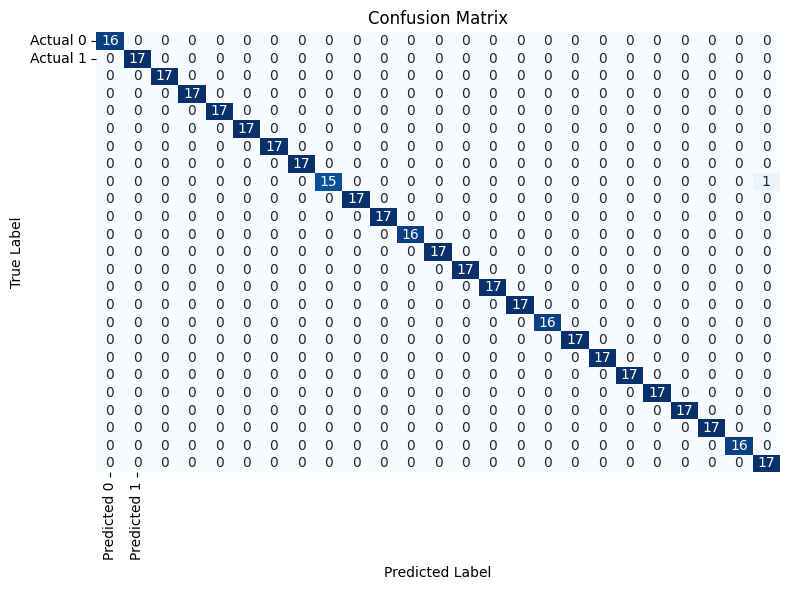

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import logging

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

# Print classification report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

# Log results
logging.info("SVM Accuracy: %.4f", accuracy)
logging.info("Classification Report:\n%s", report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot with class labels
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# Define Prediction Utilities

In [ ]:
skills_list = [
    'Python', 'Data Analysis', 'Machine Learning', 'Communication', 'Project Management', 'Deep Learning', 'SQL', 'Tableau',
    'Java', 'C++', 'JavaScript', 'HTML', 'CSS', 'React', 'Angular', 'Node.js', 'MongoDB', 'Express.js', 'Git',
    'Research', 'Statistics', 'Quantitative Analysis', 'Qualitative Analysis', 'SPSS', 'R', 'Data Visualization', 'Matplotlib',
    'Seaborn', 'Plotly', 'Pandas', 'Numpy', 'Scikit-learn', 'TensorFlow', 'Keras', 'PyTorch', 'NLTK', 'Text Mining',
    'Natural Language Processing', 'Computer Vision', 'Image Processing', 'OCR', 'Speech Recognition', 'Recommendation Systems',
    'Collaborative Filtering', 'Content-Based Filtering', 'Reinforcement Learning', 'Neural Networks', 'Convolutional Neural Networks',
    'Recurrent Neural Networks', 'Generative Adversarial Networks', 'XGBoost', 'Random Forest', 'Decision Trees', 'Support Vector Machines',
    'Linear Regression', 'Logistic Regression', 'K-Means Clustering', 'Hierarchical Clustering', 'DBSCAN', 'Association Rule Learning',
    'Apache Hadoop', 'Apache Spark', 'MapReduce', 'Hive', 'HBase', 'Apache Kafka', 'Data Warehousing', 'ETL', 'Big Data Analytics',
    'Cloud Computing', 'Amazon Web Services (AWS)', 'Microsoft Azure', 'Google Cloud Platform (GCP)', 'Docker', 'Kubernetes', 'Linux',
    'Shell Scripting', 'Cybersecurity', 'Network Security', 'Penetration Testing', 'Firewalls', 'Encryption', 'Malware Analysis',
    'Digital Forensics', 'CI/CD', 'DevOps', 'Agile Methodology', 'Scrum', 'Kanban', 'Continuous Integration', 'Continuous Deployment',
    'Software Development', 'Web Development', 'Mobile Development', 'Backend Development', 'Frontend Development', 'Full-Stack Development',
    'UI/UX Design', 'Responsive Design', 'Wireframing', 'Prototyping', 'User Testing', 'Adobe Creative Suite', 'Photoshop', 'Illustrator',
    'InDesign', 'Figma', 'Sketch', 'Zeplin', 'InVision', 'Product Management', 'Market Research', 'Customer Development', 'Lean Startup',
    'Business Development', 'Sales', 'Marketing', 'Content Marketing', 'Social Media Marketing', 'Email Marketing', 'SEO', 'SEM', 'PPC',
    'Google Analytics', 'Facebook Ads', 'LinkedIn Ads', 'Lead Generation', 'Customer Relationship Management (CRM)', 'Salesforce',
    'HubSpot', 'Zendesk', 'Intercom', 'Customer Support', 'Technical Support', 'Troubleshooting', 'Ticketing Systems', 'ServiceNow',
    'ITIL', 'Quality Assurance', 'Manual Testing', 'Automated Testing', 'Selenium', 'JUnit', 'Load Testing', 'Performance Testing',
    'Regression Testing', 'Black Box Testing', 'White Box Testing', 'API Testing', 'Mobile Testing', 'Usability Testing', 'Accessibility Testing',
    'Cross-Browser Testing', 'Agile Testing', 'User Acceptance Testing', 'Software Documentation', 'Technical Writing', 'Copywriting',
    'Editing', 'Proofreading', 'Content Management Systems (CMS)', 'WordPress', 'Joomla', 'Drupal', 'Magento', 'Shopify', 'E-commerce',
    'Payment Gateways', 'Inventory Management', 'Supply Chain Management', 'Logistics', 'Procurement', 'ERP Systems', 'SAP', 'Oracle',
    'Microsoft Dynamics', 'Tableau', 'Power BI', 'QlikView', 'Looker', 'Data Warehousing', 'ETL', 'Data Engineering', 'Data Governance',
    'Data Quality', 'Master Data Management', 'Predictive Analytics', 'Prescriptive Analytics', 'Descriptive Analytics', 'Business Intelligence',
    'Dashboarding', 'Reporting', 'Data Mining', 'Web Scraping', 'API Integration', 'RESTful APIs', 'GraphQL', 'SOAP', 'Microservices',
    'Serverless Architecture', 'Lambda Functions', 'Event-Driven Architecture', 'Message Queues', 'GraphQL', 'Socket.io', 'WebSockets'
'Ruby', 'Ruby on Rails', 'PHP', 'Symfony', 'Laravel', 'CakePHP', 'Zend Framework', 'ASP.NET', 'C#', 'VB.NET', 'ASP.NET MVC', 'Entity Framework',
    'Spring', 'Hibernate', 'Struts', 'Kotlin', 'Swift', 'Objective-C', 'iOS Development', 'Android Development', 'Flutter', 'React Native', 'Ionic',
    'Mobile UI/UX Design', 'Material Design', 'SwiftUI', 'RxJava', 'RxSwift', 'Django', 'Flask', 'FastAPI', 'Falcon', 'Tornado', 'WebSockets',
    'GraphQL', 'RESTful Web Services', 'SOAP', 'Microservices Architecture', 'Serverless Computing', 'AWS Lambda', 'Google Cloud Functions',
    'Azure Functions', 'Server Administration', 'System Administration', 'Network Administration', 'Database Administration', 'MySQL', 'PostgreSQL',
    'SQLite', 'Microsoft SQL Server', 'Oracle Database', 'NoSQL', 'MongoDB', 'Cassandra', 'Redis', 'Elasticsearch', 'Firebase', 'Google Analytics',
    'Google Tag Manager', 'Adobe Analytics', 'Marketing Automation', 'Customer Data Platforms', 'Segment', 'Salesforce Marketing Cloud', 'HubSpot CRM',
    'Zapier', 'IFTTT', 'Workflow Automation', 'Robotic Process Automation (RPA)', 'UI Automation', 'Natural Language Generation (NLG)',
    'Virtual Reality (VR)', 'Augmented Reality (AR)', 'Mixed Reality (MR)', 'Unity', 'Unreal Engine', '3D Modeling', 'Animation', 'Motion Graphics',
    'Game Design', 'Game Development', 'Level Design', 'Unity3D', 'Unreal Engine 4', 'Blender', 'Maya', 'Adobe After Effects', 'Adobe Premiere Pro',
    'Final Cut Pro', 'Video Editing', 'Audio Editing', 'Sound Design', 'Music Production', 'Digital Marketing', 'Content Strategy', 'Conversion Rate Optimization (CRO)',
    'A/B Testing', 'Customer Experience (CX)', 'User Experience (UX)', 'User Interface (UI)', 'Persona Development', 'User Journey Mapping', 'Information Architecture (IA)',
    'Wireframing', 'Prototyping', 'Usability Testing', 'Accessibility Compliance', 'Internationalization (I18n)', 'Localization (L10n)', 'Voice User Interface (VUI)',
    'Chatbots', 'Natural Language Understanding (NLU)', 'Speech Synthesis', 'Emotion Detection', 'Sentiment Analysis', 'Image Recognition', 'Object Detection',
    'Facial Recognition', 'Gesture Recognition', 'Document Recognition', 'Fraud Detection', 'Cyber Threat Intelligence', 'Security Information and Event Management (SIEM)',
    'Vulnerability Assessment', 'Incident Response', 'Forensic Analysis', 'Security Operations Center (SOC)', 'Identity and Access Management (IAM)', 'Single Sign-On (SSO)',
    'Multi-Factor Authentication (MFA)', 'Blockchain', 'Cryptocurrency', 'Decentralized Finance (DeFi)', 'Smart Contracts', 'Web3', 'Non-Fungible Tokens (NFTs)']

def extract_skills_from_resume(text, skills_list):
    skills = []
    for skill in skills_list:
        pattern = r"\b{}\b".format(re.escape(skill))
        if re.search(pattern, text, re.IGNORECASE):
            skills.append(skill)
    return skills

def predict_category(pdf_path, model, tfidf, le, skills_list):
    try:
        text = extract_text(pdf_path)
        if not text:
            return "Error: No text extracted", []
        cleaned_text = clean_resume(text)
        extracted_skills = extract_skills_from_resume(text, skills_list)
        vectorized_input = tfidf.transform([cleaned_text])
        predicted_label = model.predict(vectorized_input)
        predicted_category = le.inverse_transform(predicted_label)[0]
        return predicted_category, extracted_skills
    except Exception as e:
        logging.error("Prediction error: %s", e)
        return "Error during prediction", []


#  Run Prediction on a PDF

In [ ]:
resume_path = "/content/aryaman.pdf"  # Make sure this file is uploaded in Colab

# Run prediction
category, skills = predict_category(resume_path, model.best_estimator_, tfidf, le, skills_list)

# Display output
print("Predicted Job Category:", category)
print("Extracted Skills:", skills)

Predicted Job Category: Data Science
Extracted Skills: ['Python', 'Machine Learning', 'Deep Learning', 'SQL', 'Tableau', 'Java', 'JavaScript', 'CSS', 'React', 'Node.js', 'Git', 'Research', 'R', 'Seaborn', 'Pandas', 'Scikit-learn', 'TensorFlow', 'PyTorch', 'Cybersecurity', 'CI/CD', 'Tableau', 'Data Engineering', 'Kotlin', 'PostgreSQL', 'Firebase', 'Sentiment Analysis']
